In [ ]:
import warnings

import mlflow
import mlflow.sklearn
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

In [2]:
import os
from pathlib import Path

ROOT = Path(os.getcwd())
while not (ROOT / 'src').exists():
	ROOT = ROOT.parent

DATA = ROOT / 'data' / 'youtube'
train = pd.read_csv(DATA / 'scaled_train.csv')
val = pd.read_csv(DATA / 'scaled_val.csv')
test = pd.read_csv(DATA / 'scaled_test.csv')

In [3]:
import mlflow

mlflow.set_tracking_uri('')
mlflow.set_experiment('who_will_viral')

2026/04/12 13:17:04 INFO mlflow.tracking.fluent: Experiment with name 'who_will_viral' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///F:/CMP_4th/term%202/data%20science/who-will-viral/src/who_will_viral/models/mlruns/672183603364986581', creation_time=1775992624994, experiment_id='672183603364986581', last_update_time=1775992624994, lifecycle_stage='active', name='who_will_viral', tags={}, trace_location=None, workspace='default'>

In [4]:
TARGET = 'is_trending'
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_val, y_val = val.drop(columns=[TARGET]), val[TARGET]
X_test, y_test = test.drop(columns=[TARGET]), test[TARGET]
print('train shape', X_train.shape, ' val shape:', X_val.shape, 'test shape', X_test.shape)
print('\nClass distribution (training data):')
print(y_train.value_counts(normalize=True).round(3))

train shape (108375, 15)  val shape: (36126, 15) test shape (36126, 15)

Class distribution (training data):
is_trending
0    0.822
1    0.178
Name: proportion, dtype: float64


In [5]:
from mlflow_utilities import run_experiment

## Baseline model

  
LR baseline (no imbalance handling yet)
  accuracy: 0.9634
  f1: 0.9338
  precision: 0.9648
  recall: 0.8250
  roc_auc: 0.9768
  Wasted_Resources_False_Positive: 0.0352
  Missed_Trending_Videos: 0.1750

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     29686
           1       0.96      0.82      0.89      6440

    accuracy                           0.96     36126
   macro avg       0.96      0.91      0.93     36126
weighted avg       0.96      0.96      0.96     36126



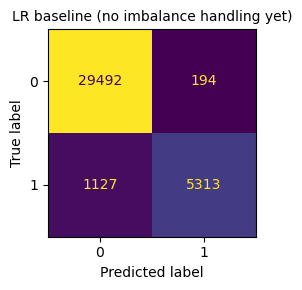

2026/04/12 13:17:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:17:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [6]:
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)

lr_base_metrics, lr_base_model = run_experiment(
	run_name='LR baseline (no imbalance handling yet)',
	model=lr_baseline,
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_train,
	y_tr=y_train,
	params={'model': 'LogisticRegression', 'imbalance': 'none', 'max_iter': 1000},
	tags={'stage': 'baseline'},
)

## Data imbalance strategies
### SMOTE

In [7]:
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(f'After SMOTE — class counts: {pd.Series(y_smote).value_counts().to_dict()}')

After SMOTE — class counts: {0: 89054, 1: 89054}


### Logistic regression after SMOTE

  
LR — SMOTE
  accuracy: 0.9394
  f1: 0.9017
  precision: 0.7909
  recall: 0.8974
  roc_auc: 0.9778
  Wasted_Resources_False_Positive: 0.2091
  Missed_Trending_Videos: 0.1026

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.79      0.90      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.88      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



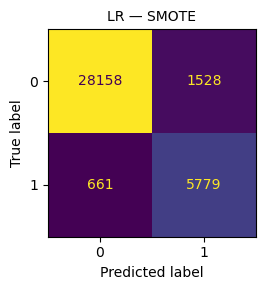

2026/04/12 13:17:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:17:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [8]:
lr_smote_metrics, lr_smote_model = run_experiment(
	run_name='LR — SMOTE',
	model=LogisticRegression(max_iter=1000, random_state=42),
	X_tr=X_smote,
	y_tr=y_smote,
	X_ev=X_val,
	y_ev=y_val,
	params={'model': 'LogisticRegression', 'imbalance': 'SMOTE'},
	tags={'stage': 'imbalance_strategy'},
)

### Logistic regression with class weights

  
LR — class_weight=balanced
  accuracy: 0.9402
  f1: 0.9028
  precision: 0.7939
  recall: 0.8974
  roc_auc: 0.9779
  Wasted_Resources_False_Positive: 0.2061
  Missed_Trending_Videos: 0.1026

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.79      0.90      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.89      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



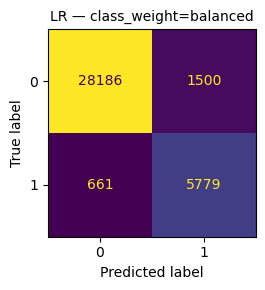

2026/04/12 13:18:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:18:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [10]:
lr_cw_metrics, lr_cw_model = run_experiment(
	run_name='LR — class_weight=balanced',
	model=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_train,
	y_tr=y_train,
	params={'model': 'LogisticRegression', 'imbalance': 'class_weight'},
	tags={'stage': 'imbalance_strategy'},
)

### Random undersampling

After undersampling: {0: 19321, 1: 19321}
  
LR — RandomUnderSampler
  accuracy: 0.9401
  f1: 0.9027
  precision: 0.7932
  recall: 0.8981
  roc_auc: 0.9779
  Wasted_Resources_False_Positive: 0.2068
  Missed_Trending_Videos: 0.1019

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.79      0.90      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.89      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



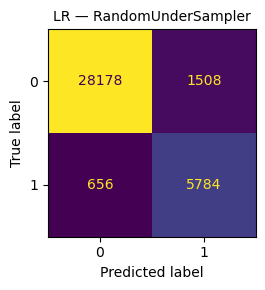

2026/04/12 13:18:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:18:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [11]:
X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)
print(f'After undersampling: {pd.Series(y_under).value_counts().to_dict()}')

lr_under_metrics, lr_under_model = run_experiment(
	run_name='LR — RandomUnderSampler',
	model=LogisticRegression(max_iter=1000, random_state=42),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_under,
	y_tr=y_under,
	params={'model': 'LogisticRegression', 'imbalance': 'RandomUnderSampler'},
	tags={'stage': 'imbalance_strategy'},
)

## SMOTETomek

After SMOTETomek: {0: 88999, 1: 88999}
  
LR — SMOTETomek
  accuracy: 0.9394
  f1: 0.9016
  precision: 0.7907
  recall: 0.8974
  roc_auc: 0.9778
  Wasted_Resources_False_Positive: 0.2093
  Missed_Trending_Videos: 0.1026

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.79      0.90      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.88      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



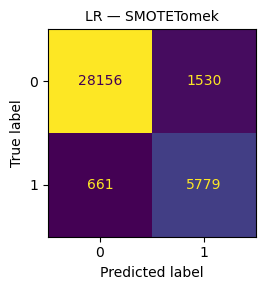

2026/04/12 13:19:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:19:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [12]:
from imblearn.combine import SMOTETomek

X_smotetomek, y_smotetomek = SMOTETomek(random_state=42).fit_resample(X_train, y_train)
print(f'After SMOTETomek: {pd.Series(y_smotetomek).value_counts().to_dict()}')

lr_st_metrics, lr_st_model = run_experiment(
	run_name='LR — SMOTETomek',
	model=LogisticRegression(max_iter=1000, random_state=42),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_smotetomek,
	y_tr=y_smotetomek,
	params={'model': 'LogisticRegression', 'imbalance': 'SMOTETomek'},
	tags={'stage': 'imbalance_strategy'},
)

# Other Models

## with SMOTE

In [13]:
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)

### Random Forest

  
Random Forest SMOTE
  accuracy: 0.9776
  f1: 0.9617
  precision: 0.9394
  recall: 0.9345
  roc_auc: 0.9947
  Wasted_Resources_False_Positive: 0.0606
  Missed_Trending_Videos: 0.0655

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29686
           1       0.94      0.93      0.94      6440

    accuracy                           0.98     36126
   macro avg       0.96      0.96      0.96     36126
weighted avg       0.98      0.98      0.98     36126



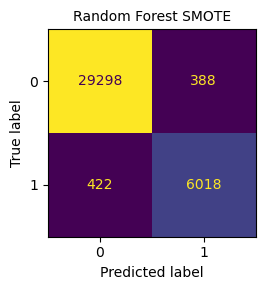

2026/04/12 13:19:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:19:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [14]:
rf_metrics, rf_model = run_experiment(
	run_name='Random Forest SMOTE',
	model=RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_smote,
	y_tr=y_smote,
	params={'model': 'RandomForest', 'n_estimators': 200, 'max_depth': 10, 'imbalance': 'SMOTE'},
	tags={'stage': 'advanced_model'},
)

### XGBoost

  
XGBoost SMOTE
  accuracy: 0.9804
  f1: 0.9666
  precision: 0.9448
  recall: 0.9455
  roc_auc: 0.9955
  Wasted_Resources_False_Positive: 0.0552
  Missed_Trending_Videos: 0.0545

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29686
           1       0.94      0.95      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.97      0.97      0.97     36126
weighted avg       0.98      0.98      0.98     36126



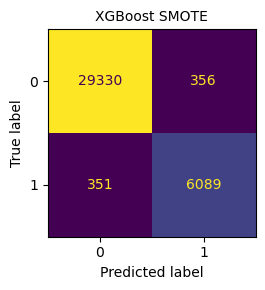

2026/04/12 13:19:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:19:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [15]:
xgb_metrics, xgb_model = run_experiment(
	run_name='XGBoost SMOTE',
	model=XGBClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_smote,
	y_tr=y_smote,
	params={'model': 'XGBoost', 'n_estimators': 200, 'max_depth': 10, 'imbalance': 'SMOTE'},
	tags={'stage': 'advanced_model'},
)

## with class weights

### Random forest

  
Random Forest class weights
  accuracy: 0.9789
  f1: 0.9636
  precision: 0.9521
  recall: 0.9283
  roc_auc: 0.9948
  Wasted_Resources_False_Positive: 0.0479
  Missed_Trending_Videos: 0.0717

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     29686
           1       0.95      0.93      0.94      6440

    accuracy                           0.98     36126
   macro avg       0.97      0.96      0.96     36126
weighted avg       0.98      0.98      0.98     36126



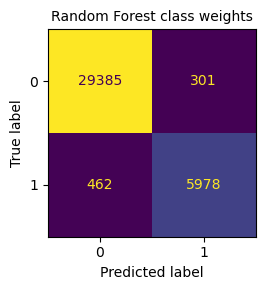

2026/04/12 13:19:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:19:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [16]:
rf_metrics, rf_model = run_experiment(
	run_name='Random Forest class weights',
	model=RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_train,
	y_tr=y_train,
	params={'model': 'RandomForest', 'n_estimators': 200, 'max_depth': 10, 'imbalance': 'class_weight'},
	tags={'stage': 'advanced_model'},
)

### XGBoost

  
XGBoost Class weights
  accuracy: 0.9822
  f1: 0.9692
  precision: 0.9664
  recall: 0.9326
  roc_auc: 0.9955
  Wasted_Resources_False_Positive: 0.0336
  Missed_Trending_Videos: 0.0674

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29686
           1       0.97      0.93      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.98      0.96      0.97     36126
weighted avg       0.98      0.98      0.98     36126



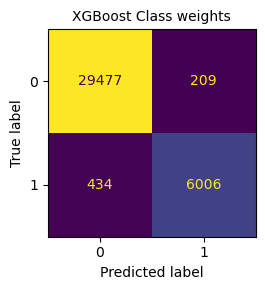

2026/04/12 13:19:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:19:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale = neg / pos


xgb_metrics, xgb_model = run_experiment(
	run_name='XGBoost Class weights',
	model=XGBClassifier(n_estimators=200, max_depth=10, random_state=42, scale_pos_weight=scale, n_jobs=-1),
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_train,
	y_tr=y_train,
	params={'model': 'XGBoost', 'n_estimators': 200, 'max_depth': 10, 'imbalance': 'class_weight'},
	tags={'stage': 'advanced_model'},
)

# hyperparameter search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5, 10]}


grid_search = GridSearchCV(
	estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
	param_grid=param_grid,
	scoring='f1_macro',
	cv=3,
	n_jobs=-1,
	verbose=1,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(grid_search.best_params_)

  
RF , GridSearch best [class weights]
  accuracy: 0.9805
  f1: 0.9664
  precision: 0.9607
  recall: 0.9289
  roc_auc: 0.9955
  Wasted_Resources_False_Positive: 0.0393
  Missed_Trending_Videos: 0.0711

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     29686
           1       0.96      0.93      0.94      6440

    accuracy                           0.98     36126
   macro avg       0.97      0.96      0.97     36126
weighted avg       0.98      0.98      0.98     36126



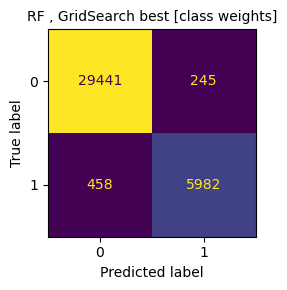

2026/04/12 13:41:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:41:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [20]:
rf_metrics, rf_model = run_experiment(
	run_name='RF , GridSearch best [class weights]',
	model=best_model,
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_train,
	y_tr=y_train,
	params={**grid_search.best_params_, 'model': 'RandomForest', 'search': 'GridSearchCV'},
	tags={'stage': 'hyperparameter_tuning'},
)

## Hyperparameter search for XGB (using optuna)

[I 2026-04-12 13:42:04,866] A new study created in memory with name: no-name-95ce6310-1f1e-408b-9ea4-bb7ec2a86832
[I 2026-04-12 13:42:08,536] Trial 0 finished with value: 0.9615235492188914 and parameters: {'n_estimators': 284, 'max_depth': 9, 'learning_rate': 0.028701171542597145, 'subsample': 0.8835994209727329}. Best is trial 0 with value: 0.9615235492188914.
[I 2026-04-12 13:42:11,106] Trial 1 finished with value: 0.9595196430994148 and parameters: {'n_estimators': 135, 'max_depth': 10, 'learning_rate': 0.029712195156654717, 'subsample': 0.9369240775370293}. Best is trial 0 with value: 0.9615235492188914.
[I 2026-04-12 13:42:13,308] Trial 2 finished with value: 0.9662450406287058 and parameters: {'n_estimators': 173, 'max_depth': 8, 'learning_rate': 0.1038824246233169, 'subsample': 0.8668816980054495}. Best is trial 2 with value: 0.9662450406287058.
[I 2026-04-12 13:42:16,117] Trial 3 finished with value: 0.9680978063317653 and parameters: {'n_estimators': 185, 'max_depth': 10, 'le

{'n_estimators': 226, 'max_depth': 12, 'learning_rate': 0.1860520524265147, 'subsample': 0.7691811697604709}
  
XGBoost, Optuna best, class weights
  accuracy: 0.9828
  f1: 0.9702
  precision: 0.9693
  recall: 0.9331
  roc_auc: 0.9957
  Wasted_Resources_False_Positive: 0.0307
  Missed_Trending_Videos: 0.0669

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29686
           1       0.97      0.93      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.98      0.96      0.97     36126
weighted avg       0.98      0.98      0.98     36126



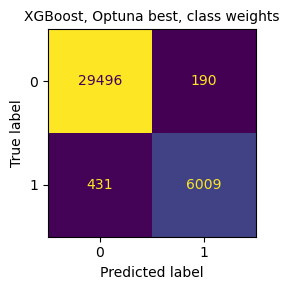

2026/04/12 13:47:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:47:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


({'accuracy': 0.9828101644245142,
  'f1': 0.9702245875643927,
  'precision': 0.9693498951443781,
  'recall': 0.9330745341614907,
  'roc_auc': 0.9956936876156777,
  'Wasted_Resources_False_Positive': 0.030650104855621873,
  'Missed_Trending_Videos': 0.06692546583850932},
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1860520524265147, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=12, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_esti

In [21]:
import optuna
from sklearn.metrics import f1_score
from xgboost import XGBClassifier


def objective(trial):
	params = {
		'n_estimators': trial.suggest_int('n_estimators', 100, 500),
		'max_depth': trial.suggest_int('max_depth', 3, 15),
		'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
		'subsample': trial.suggest_float('subsample', 0.6, 1.0),
		'scale_pos_weight': neg / pos,
		'random_state': 42,
		'n_jobs': -1,
	}
	model = XGBClassifier(**params)
	model.fit(X_train, y_train)
	preds = model.predict(X_val)
	return f1_score(y_val, preds, average='macro')


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(study.best_params)

best_xgb = XGBClassifier(**study.best_params, scale_pos_weight=neg / pos, random_state=42)
run_experiment(
	run_name='XGBoost, Optuna best, class weights',
	model=best_xgb,
	X_ev=X_val,
	y_ev=y_val,
	X_tr=X_train,
	y_tr=y_train,
	params={**study.best_params, 'model': 'XGBoost', 'search': 'Optuna'},
	tags={'stage': 'hyperparameter_tuning'},
)